In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Perceptron

#Cargo el dataset Iris
iris = datasets.load_iris()
#Usamos solo las columnas: longitud de sépalo y longitud de pétalo
X = iris.data[:, [0, 2]] 
y = iris.target

In [11]:
#Experimento A: Setosa (clase 0) vs Versicolor (clase 1)
# Filtramos solo esas dos clases
mask_a = (y == 0) | (y == 1)
X_a, y_a = X[mask_a], y[mask_a]

#Experimento B: Versicolor (clase 1) vs Virgínica (clase 2)
# Filtramos solo esas dos clases
mask_b = (y == 1) | (y == 2)
X_b, y_b = X[mask_b], y[mask_b]

#Entrenamos los perceptrones
mod_a = Perceptron(random_state=20).fit(X_a, y_a)
mod_b = Perceptron(max_iter=1000, tol=1e-6,random_state=20).fit(X_b, y_b)
#En el segundo las clases no son linealmente separables así que le tengo que poner número máximo de iteraciones porque sino
#el perceptrón no converge.



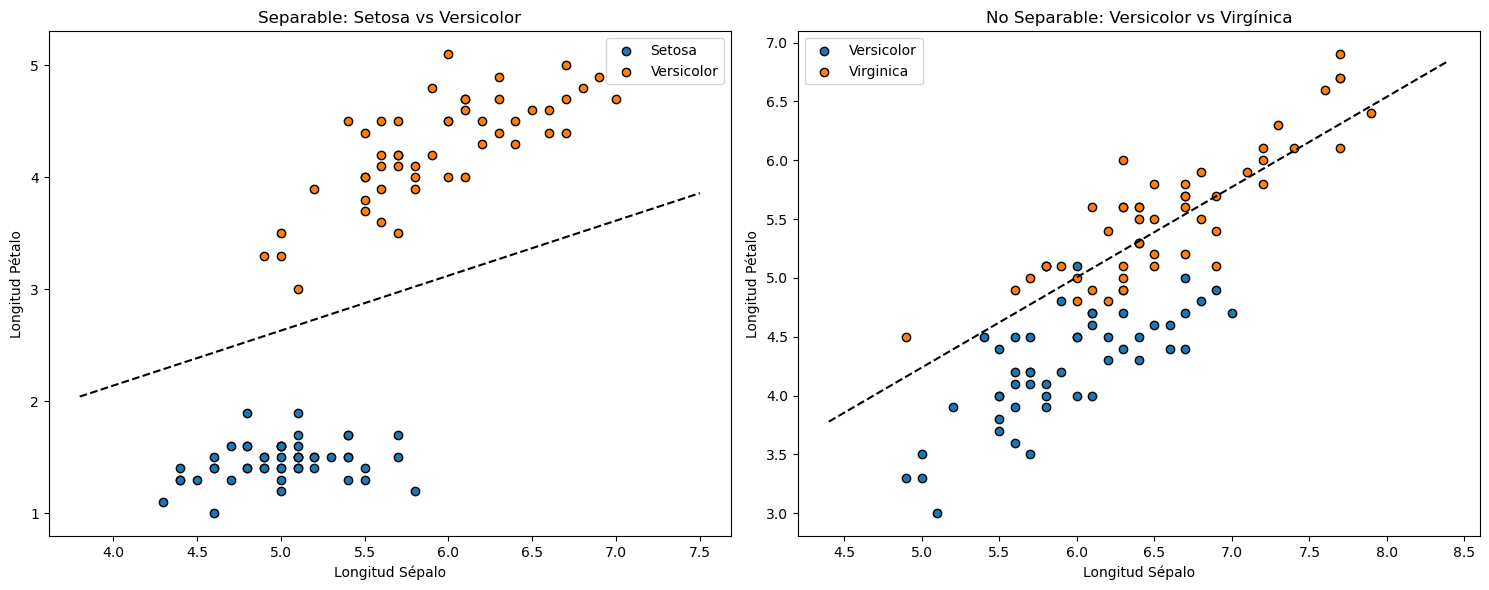

In [12]:
#Muestro los resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

def plot_perceptron(ax, mod, X_data, y_data, title, labels):
    #Dibujamos los puntos
    for i, label in enumerate(np.unique(y_data)):
        ax.scatter(X_data[y_data==label, 0], X_data[y_data==label, 1], label=labels[i], edgecolors='k')
    
    #Dibujamos frontera de decisión
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    xx = np.linspace(x_min, x_max, 100)
    w = mod.coef_[0]
    b = mod.intercept_[0]
    #La ecuación es w1*x1 + w2*x2 + b = 0 -> x2 = -(w1*x1 + b) / w2
    yy = -(w[0] * xx + b) / w[1]
    ax.plot(xx, yy, 'k--')
    ax.set_title(title)
    ax.set_xlabel('Longitud Sépalo')
    ax.set_ylabel('Longitud Pétalo')
    ax.legend()

plot_perceptron(ax1, mod_a, X_a, y_a, "Separable: Setosa vs Versicolor", ['Setosa', 'Versicolor'])
plot_perceptron(ax2, mod_b, X_b, y_b, "No Separable: Versicolor vs Virgínica", ['Versicolor', 'Virginica'])

plt.tight_layout()
plt.show()